# Diabetes Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete, reproducible, and academically rigorous classification experiment using the Diabetes dataset.

The experiment evaluates three model groups:

1. **Baseline machine learning classifiers**
2. **COBRA-based aggregation** using `CombinedClassifier`
3. **KFCProcedure classification** using `KFCClassifier`

The notebook is designed as an experimental appendix and as supporting evidence for **Chapter 7: Experiments and Results** of the thesis.


## 1. Objective

### Purpose

The purpose of this experiment is to evaluate classification performance on the Diabetes dataset using standard baseline classifiers, COBRA-based aggregation, and the KFCProcedure framework.

The experiment is designed to compare conventional supervised learning models against a hybrid framework that combines divergence-based clustering, cluster-wise local learning, and prediction-space aggregation.

### Research Questions

This experiment addresses the following research questions:

1. How do standard machine learning classifiers perform on the Diabetes classification task?
2. How does `CombinedClassifier` compare with the individual baseline classifiers?
3. How does `KFCClassifier` compare with baseline classifiers and standalone COBRA-based aggregation?
4. Are the observed results stable across repeated train-test splits?

### Expected Evaluation

Since the task is classification, the experiment evaluates models using:

- Accuracy
- Precision
- Recall
- F1-score

The experiment uses repeated evaluation with the required random seeds:

```python
SEEDS = [42, 52, 62, 72, 82]
```

For each seed, the dataset is split, preprocessed, trained, predicted, and evaluated independently.


## 2. Dataset Description

### 2.1 Dataset Overview

The dataset used in this experiment is the Diabetes dataset from Kaggle, as used in the repository notebook.

The repository notebook loads the dataset from:

```text
mathchi/diabetes-data-set
```

The dataset file used by the notebook is:

```text
diabetes.csv
```

### 2.2 Feature Description

The observable feature columns in the repository notebook are:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

The detailed clinical interpretation of each feature is not expanded in the provided repository notebook. Therefore, additional clinical meaning beyond the column names is **not observable from the provided materials**.

### 2.3 Target Variable

The target column is:

```text
Outcome
```

All other columns are used as input features.


## 3. Exploratory Data Analysis (EDA)

The EDA section follows the dataset and repository-supported workflow:

1. Dataset shape
2. Data types
3. Missing value analysis
4. Duplicate analysis
5. Target distribution
6. Feature statistics
7. Correlation analysis
8. Additional visualizations

Outlier removal is not applied because a formal outlier handling procedure is **not observable from the provided materials**.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


### Repository Import Configuration

This notebook uses repository modules directly:

- `CombinedClassifier`
- `KFCClassifier`

The import cell first attempts to import the package from the active Python environment. If that fails, it searches upward for a local repository structure containing `src/kfc_procedure`.


In [2]:
def find_repo_root(start_path=None):
    '''
    Locate the repository root containing src/kfc_procedure.
    '''
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )


try:
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier
    print("Imported kfc_procedure from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))

    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier

    print(f"Imported kfc_procedure from source path: {repo_root / 'src'}")


Imported kfc_procedure from installed environment.


### 3.1 Dataset Loading

The dataset is loaded using the Kaggle dataset source used in the repository notebook.

A local CSV path may be supplied through `DATASET_CSV_PATH` for offline reproducibility. If no local path is supplied, the notebook downloads the public Kaggle dataset using `kagglehub`.


In [3]:
DATASET_CSV_PATH = None  # Example: "data/diabetes.csv"
KAGGLE_DATASET = "mathchi/diabetes-data-set"
DATASET_FILENAME = "diabetes.csv"

if DATASET_CSV_PATH is not None:
    csv_path = Path(DATASET_CSV_PATH)
    if not csv_path.exists():
        raise FileNotFoundError(f"DATASET_CSV_PATH does not exist: {csv_path}")
else:
    try:
        from kagglehub import dataset_download
    except ImportError:
        %pip install kagglehub
        from kagglehub import dataset_download

    dataset_path = dataset_download(KAGGLE_DATASET)
    csv_path = Path(dataset_path) / DATASET_FILENAME

if not csv_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {csv_path}")

df_raw = pd.read_csv(csv_path)

df_raw.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3.2 Dataset Shape

The following cell reports the raw dataset shape before any cleaning operation.


In [4]:
print("Raw dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])


Raw dataset shape: (768, 9)
Number of rows: 768
Number of columns: 9


### 3.3 Data Types

The following table shows the data type of each column.


In [5]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

display(data_types_table)


,Feature,Data Type
0,Pregnancies,int64
1,Glucose,int64
2,BloodPressure,int64
3,SkinThickness,int64
4,Insulin,int64
5,BMI,float64
6,DiabetesPedigreeFunction,float64
7,Age,int64
8,Outcome,int64


### 3.4 Missing Value Analysis

Missing values are checked using:

```python
df.isnull().sum()
```

The repository notebook checked missing values with this method and did not define an imputation procedure.


In [6]:
missing_values_table = df_raw.isnull().sum().reset_index()
missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = missing_values_table["Missing Values"] / len(df_raw) * 100

display(missing_values_table)

print("Total missing values:", int(df_raw.isnull().sum().sum()))


,Feature,Missing Values,Missing Percentage
0,Pregnancies,0,0.0
1,Glucose,0,0.0
2,BloodPressure,0,0.0
3,SkinThickness,0,0.0
4,Insulin,0,0.0
5,BMI,0,0.0
6,DiabetesPedigreeFunction,0,0.0
7,Age,0,0.0
8,Outcome,0,0.0


Total missing values: 0


### 3.5 Duplicate Analysis

Duplicate analysis is included for transparency. A duplicate removal procedure for the Diabetes notebook is **not observable from the provided materials**. Therefore, duplicate counts are reported, but duplicate removal is not applied unless the repository procedure explicitly defines it.


In [7]:
duplicate_count = int(df_raw.duplicated().sum())
duplicate_percentage = duplicate_count / len(df_raw) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 4), "%")


Duplicate rows: 0
Duplicate percentage: 0.0 %


### 3.6 Target Distribution

The repository notebook visualized the target distribution using `Outcome`.


In [8]:
TARGET_COLUMN = "Outcome"

if TARGET_COLUMN not in df_raw.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' was not found in the dataset.")

target_distribution_table = (
    df_raw[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .reset_index()
)
target_distribution_table.columns = ["Outcome", "Count"]
target_distribution_table["Percentage"] = (
    target_distribution_table["Count"] / target_distribution_table["Count"].sum() * 100
)

display(target_distribution_table)


,Outcome,Count,Percentage
0,0,500,65.104167
1,1,268,34.895833


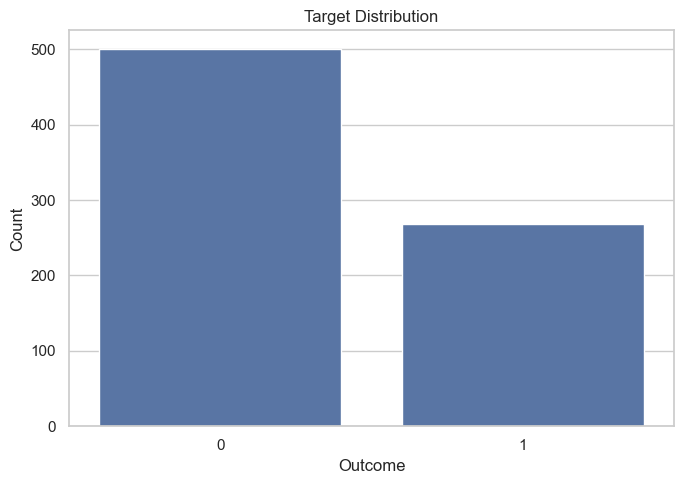

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_raw, x=TARGET_COLUMN)
plt.title("Target Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.7 Feature Statistics

The following table reports descriptive statistics for the numerical columns.


In [10]:
feature_statistics_table = df_raw.describe().T

display(feature_statistics_table)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 3.8 Correlation Analysis

The repository notebook visualized the correlation matrix using a heatmap.


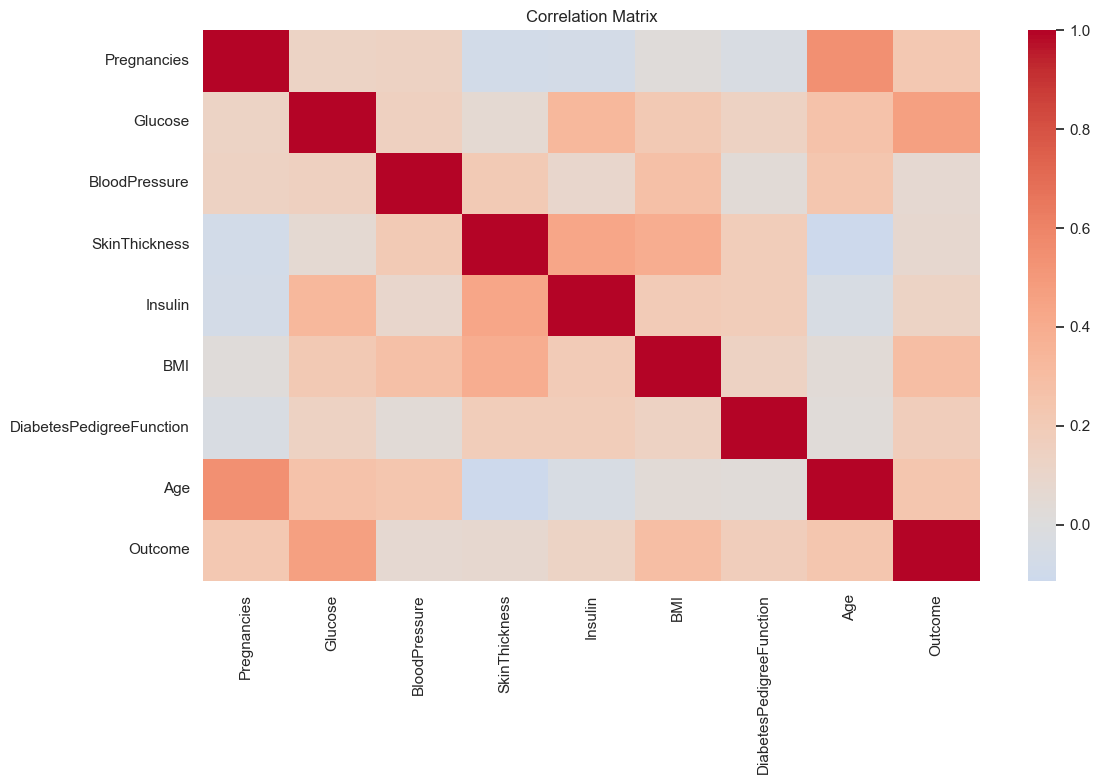

In [11]:
correlation_matrix = df_raw.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.9 Additional Visualizations

The following visualization reports the absolute correlation between each feature and the target variable. This is used only for exploratory interpretation and is not used as a feature selection rule.


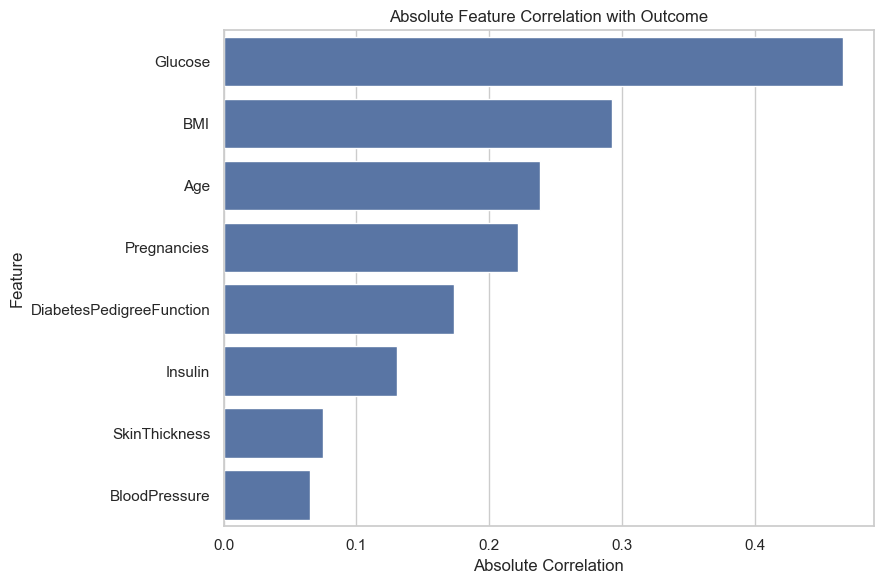

In [12]:
target_correlations = (
    correlation_matrix[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=target_correlations.values, y=target_correlations.index)
plt.title("Absolute Feature Correlation with Outcome")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_target_correlation_bar.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Data Cleaning

### 4.1 Missing Value Handling

The repository notebook checks missing values using `df.isnull().sum()`. An imputation procedure is not defined in the provided Diabetes notebook.

If the dataset contains no missing values, no imputation is applied.

### 4.2 Duplicate Removal

Duplicate removal for the Diabetes notebook is **not observable from the provided materials**. Therefore, this experiment reports duplicate counts but keeps the dataset unchanged.

### 4.3 Outlier Inspection

A formal outlier inspection or removal strategy is **not observable from the provided materials**. Therefore, no outlier filtering is applied.

### 4.4 Data Consistency Checks

The notebook verifies that:

- the target column exists,
- the target has at least two classes,
- all model input columns are numeric,
- there are no missing values under the repository-supported missing-value check.


In [13]:
df = df_raw.copy()

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Required target column '{TARGET_COLUMN}' is missing.")

if df[TARGET_COLUMN].nunique() < 2:
    raise ValueError("The target variable must contain at least two classes.")

non_numeric_columns = df.drop(columns=[TARGET_COLUMN]).select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric feature columns found: {non_numeric_columns}")

if df.isnull().sum().sum() == 0:
    print("Missing value handling: no imputation applied because no missing values were found.")
else:
    raise ValueError("Missing values were found, but imputation is not defined in the provided materials.")

print("Duplicate removal: Not observable from the provided materials; dataset retained unchanged.")
print("Outlier removal: Not observable from the provided materials; no outlier filtering applied.")
print("Final cleaned dataset shape:", df.shape)


Missing value handling: no imputation applied because no missing values were found.
Duplicate removal: Not observable from the provided materials; dataset retained unchanged.
Outlier removal: Not observable from the provided materials; no outlier filtering applied.
Final cleaned dataset shape: (768, 9)


## 5. Data Preprocessing

### 5.1 Feature Encoding

Additional feature encoding is **not observable from the provided materials**. The dataset columns are already numerical or numerically encoded.

### 5.2 Feature Scaling

The repository Diabetes notebook applies `MinMaxScaler(feature_range=(0.05, 0.95))` for the KFCClassifier experiment. This scaling is necessary because some divergence functions require positive feature values.

To remain repository-consistent:

- Baseline models and `CombinedClassifier` use the original feature values, matching the provided Diabetes notebook.
- `KFCClassifier` uses the MinMax-scaled feature matrix, matching the provided Diabetes notebook.

This difference is reported as a limitation because some baseline models are also sensitive to feature scaling.

### 5.3 Feature Selection

Feature selection is **not observable from the provided materials**. Therefore, all columns except `Outcome` are used as input features.

### 5.4 Final Feature Matrix

The feature matrix is:

```python
X = df.drop(columns=["Outcome"])
```

The target vector is:

```python
y = df["Outcome"]
```


In [14]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature columns:")
print(X.columns.tolist())


Feature matrix shape: (768, 8)
Target vector shape: (768,)
Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 6. Experimental Setup

### 6.1 Environment Configuration

The following cell records the execution environment for reproducibility.


In [15]:
environment_info = {
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Scikit-learn": sklearn.__version__,
}

environment_table = pd.DataFrame(environment_info.items(), columns=["Component", "Version"])

display(environment_table)


,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


### 6.2 Random Seed Configuration

The required repeated evaluation seeds are used exactly:

```python
SEEDS = [42, 52, 62, 72, 82]
```


In [16]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
SCALER_RANGE = (0.05, 0.95)
PRIMARY_METRIC = "Accuracy"

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("KFC scaler range:", SCALER_RANGE)
print("Primary ranking metric:", PRIMARY_METRIC)


Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
KFC scaler range: (0.05, 0.95)
Primary ranking metric: Accuracy


### 6.3 Train-Test Split Strategy

For every seed, the dataset is split using:

```python
train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=seed,
)
```

The split is stratified on the target variable to preserve the class distribution in both training and testing sets.

### 6.4 Hyperparameter Configuration

The repository Diabetes notebook evaluates the following baseline model families:

- Logistic Regression
- Random Forest Classifier
- SVC
- KNeighborsClassifier
- GaussianNB

The COBRA experiment uses:

- `CombinedClassifier`

The KFCProcedure experiment uses:

- `KFCClassifier`
- divergences: `['euclidean', 'gkl', 'is', 'logistic']`
- local model: `logistic_regression`
- combiner: `combined_classifier`
- number of clusters: `4`

A standalone Decision Tree baseline is not included because it is **not observable from the provided Diabetes notebook** as a separately evaluated model.

### 6.5 Evaluation Protocol

For each seed:

1. Split the dataset.
2. Train each baseline model on the raw training split.
3. Train `CombinedClassifier` on the raw training split.
4. Fit `MinMaxScaler(feature_range=(0.05, 0.95))` on the training split only.
5. Train `KFCClassifier` on the scaled training split.
6. Predict on the corresponding test split.
7. Store all metrics in `all_results`.


## 7. Evaluation Metrics

The task is classification, so the following metrics are used.

Let:

- TP = true positives
- TN = true negatives
- FP = false positives
- FN = false negatives

### Accuracy

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

Scikit-learn implementation:

```python
accuracy_score(y_true, y_pred)
```

### Precision

\[
Precision = \frac{TP}{TP + FP}
\]

Scikit-learn implementation:

```python
precision_score(y_true, y_pred, average="weighted", zero_division=0)
```

### Recall

\[
Recall = \frac{TP}{TP + FN}
\]

Scikit-learn implementation:

```python
recall_score(y_true, y_pred, average="weighted", zero_division=0)
```

### F1-score

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

Scikit-learn implementation:

```python
f1_score(y_true, y_pred, average="weighted", zero_division=0)
```


In [17]:
def evaluate_classification(y_true, y_pred, average="weighted"):
    '''
    Evaluate classification predictions using the repository-supported metrics.
    '''
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


## 8. Baseline Models

For each baseline model, the experiment performs:

1. Configuration
2. Training
3. Prediction
4. Evaluation

The baseline model families are the same as those used in the repository Diabetes notebook.


In [18]:
def make_baseline_models(seed):
    '''
    Create baseline classifiers for one seed-specific experiment.

    Random-state parameters are assigned where the sklearn estimator exposes
    them, to support reproducibility while keeping the same model families as
    the repository notebook.
    '''
    return {
        "Logistic Regression": LogisticRegression(random_state=seed),
        "Random Forest Classifier": RandomForestClassifier(random_state=seed),
        "SVC": SVC(probability=True, random_state=seed),
        "KNeighborsClassifier": KNeighborsClassifier(),
        "GaussianNB": GaussianNB(),
    }


## 9. COBRA Experiments

### Configuration

The classification-appropriate COBRA model used here is `CombinedClassifier`.

The repository Diabetes notebook uses `CombinedClassifier` with the same baseline estimator identifiers:

```python
[
    "logistic_regression",
    "random_forest_classifier",
    "svc",
    "k_neighbors_classifier",
    "gaussian_nb",
]
```

### Training

For each seed, `CombinedClassifier` is trained on the same raw training split as the baseline models.

### Prediction

Predictions are generated on the same seed-specific test split.

### Evaluation

The same classification metrics are used for fair reporting.

`GradientCOBRA` and `MixCOBRARegressor` are not used because they are regression-oriented. Their use for this classification experiment would be inappropriate.


In [19]:
COBRA_ESTIMATOR_NAMES = [
    "logistic_regression",
    "random_forest_classifier",
    "svc",
    "k_neighbors_classifier",
    "gaussian_nb",
]


def make_combined_classifier(seed):
    '''
    Create CombinedClassifier using repository-supported estimator identifiers.
    '''
    return CombinedClassifier(
        estimators=COBRA_ESTIMATOR_NAMES,
        estimators_params={
            "logistic_regression": {"random_state": seed},
            "random_forest_classifier": {"random_state": seed},
            "svc": {"probability": True, "random_state": seed},
        },
        random_state=seed,
    )


## 10. KFCProcedure Experiments

### Configuration

The KFCProcedure experiment uses `KFCClassifier`.

### K-Step

The K-Step performs divergence-based clustering using:

- Euclidean divergence
- Generalized KL divergence
- Itakura-Saito divergence
- Logistic divergence

### F-Step

The F-Step trains cluster-wise local models using:

- Logistic Regression

### C-Step

The C-Step aggregates divergence-level intermediate predictions using:

- `combined_classifier`

### Training

The model is trained on the MinMax-scaled feature matrix. The scaler is fitted only on the training split for each seed.

### Prediction

Predictions are generated on the corresponding scaled test split.

### Evaluation

The same classification metrics are used for all models.


In [20]:
def make_kfc_classifier(seed):
    '''
    Create the repository-supported KFCClassifier configuration for the Diabetes classification experiment.
    '''
    return KFCClassifier(
        divergences=["euclidean", "gkl", "is", "logistic"],
        local_model="logistic_regression",
        local_model_params={"random_state": seed},
        combiner="combined_classifier",
        combiner_params={
            "estimators": COBRA_ESTIMATOR_NAMES,
            "estimators_params": {
                "logistic_regression": {"random_state": seed},
                "random_forest_classifier": {"random_state": seed},
                "svc": {"probability": True, "random_state": seed},
            },
        },
        n_clusters=4,
        random_state=seed,
    )


## 11. Repeated Experiment Execution

The following functions execute one complete experiment run for a single seed and then repeat the process over all required seeds.

Each result record stores:

- Model
- Seed
- Accuracy
- Precision
- Recall
- F1-score
- Fit Time
- Prediction Time
- Status
- Error Message

If a model fails in a specific environment, the notebook records the failure transparently instead of fabricating a metric value.


In [21]:
METRIC_COLUMNS = ["Accuracy", "Precision", "Recall", "F1 Score"]


def empty_failure_record(model_name, seed, fit_time, error):
    return {
        "Model": model_name,
        "Seed": seed,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1 Score": np.nan,
        "Fit Time": fit_time,
        "Prediction Time": np.nan,
        "Status": "failed",
        "Error Message": str(error),
    }


def success_record(model_name, seed, metrics, fit_time, prediction_time):
    return {
        "Model": model_name,
        "Seed": seed,
        **metrics,
        "Fit Time": fit_time,
        "Prediction Time": prediction_time,
        "Status": "success",
        "Error Message": "",
    }


def train_predict_evaluate(model_name, model, X_train, X_test, y_train, y_test, seed):
    '''
    Train, predict, and evaluate one model while recording timing information.
    '''
    start_fit = time.perf_counter()

    try:
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test)
        prediction_time = time.perf_counter() - start_predict

        metrics = evaluate_classification(y_test, y_pred)
        return success_record(model_name, seed, metrics, fit_time, prediction_time)

    except Exception as error:
        fit_time = time.perf_counter() - start_fit
        return empty_failure_record(model_name, seed, fit_time, error)


In [22]:
def run_single_seed_experiment(seed, X, y):
    '''
    Run one complete seed-specific classification experiment.
    '''
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=seed,
    )

    seed_results = []

    # Baseline models use the raw feature values to match the provided Diabetes notebook.
    baseline_models = make_baseline_models(seed)
    for model_name, model in baseline_models.items():
        result = train_predict_evaluate(
            model_name=model_name,
            model=model,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            seed=seed,
        )
        seed_results.append(result)

    # COBRA CombinedClassifier uses the same raw split as the baseline models.
    combined_classifier = make_combined_classifier(seed)
    result = train_predict_evaluate(
        model_name="CombinedClassifier",
        model=combined_classifier,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        seed=seed,
    )
    seed_results.append(result)

    # KFCClassifier uses MinMax scaling to keep feature values positive for divergence-based clustering.
    scaler = MinMaxScaler(feature_range=SCALER_RANGE)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    kfc_classifier = make_kfc_classifier(seed)
    result = train_predict_evaluate(
        model_name="KFCClassifier",
        model=kfc_classifier,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=y_train,
        y_test=y_test,
        seed=seed,
    )
    seed_results.append(result)

    return seed_results


In [23]:
def run_repeated_experiment(X, y, seeds):
    '''
    Run the full repeated evaluation protocol.
    '''
    all_results = []

    for seed in seeds:
        print(f"Running experiment for seed = {seed}")
        seed_results = run_single_seed_experiment(seed, X, y)
        all_results.extend(seed_results)

    return all_results


if __name__ == "__main__":
    all_results = []
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table


Running experiment for seed = 42


search: 100%|██████████| 300/300 [00:00<00:00, 382.69it/s]


Running experiment for seed = 52


search: 100%|██████████| 300/300 [00:00<00:00, 362.50it/s]


Running experiment for seed = 62


...

Running experiment for seed = 72


search: 100%|██████████| 300/300 [00:00<00:00, 367.89it/s]


Running experiment for seed = 82


search: 100%|██████████| 300/300 [00:00<00:00, 385.95it/s]


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time,Status,Error Message
0,Logistic Regression,42,0.714286,0.706464,0.714286,0.708352,0.005961,0.000599,success,
1,Random Forest Classifier,42,0.772727,0.767640,0.772727,0.767290,0.057914,0.003229,success,
2,SVC,42,0.720779,0.710619,0.720779,0.703087,0.014081,0.001773,success,
3,KNeighborsClassifier,42,0.668831,0.662249,0.668831,0.664832,0.000617,0.000860,success,
4,GaussianNB,42,0.707792,0.717880,0.707792,0.711386,0.000762,0.000414,success,
5,CombinedClassifier,42,0.720779,0.710299,0.720779,0.705635,1.157955,0.008062,success,
6,KFCClassifier,42,0.727273,0.717703,0.727273,0.713658,0.981627,0.003033,success,
7,Logistic Regression,52,0.818182,0.819019,0.818182,0.810589,0.006111,0.000438,success,
8,Random Forest Classifier,52,0.733766,0.725111,0.733766,0.723675,0.057177,0.003377,success,
9,SVC,52,0.785714,0.795624,0.785714,0.767773,0.014460,0.001836,success,


## 12. Results Summary

### 12.1 Per-Seed Results

The per-seed table reports model performance for every random seed. This table is important because it shows whether performance is stable across different train-test splits.


In [24]:
per_seed_results_table = per_seed_results_table[
    [
        "Model",
        "Seed",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Fit Time",
        "Prediction Time",
        "Status",
        "Error Message",
    ]
].sort_values(["Seed", "Model"]).reset_index(drop=True)

per_seed_results_table.to_csv(TABLE_DIR / "diabetes_per_seed_results.csv", index=False)

display(per_seed_results_table)


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time,Status,Error Message
0,CombinedClassifier,42,0.720779,0.710299,0.720779,0.705635,1.157955,0.008062,success,
1,GaussianNB,42,0.707792,0.717880,0.707792,0.711386,0.000762,0.000414,success,
2,KFCClassifier,42,0.727273,0.717703,0.727273,0.713658,0.981627,0.003033,success,
3,KNeighborsClassifier,42,0.668831,0.662249,0.668831,0.664832,0.000617,0.000860,success,
4,Logistic Regression,42,0.714286,0.706464,0.714286,0.708352,0.005961,0.000599,success,
5,Random Forest Classifier,42,0.772727,0.767640,0.772727,0.767290,0.057914,0.003229,success,
6,SVC,42,0.720779,0.710619,0.720779,0.703087,0.014081,0.001773,success,
7,CombinedClassifier,52,0.798701,0.798202,0.798701,0.789490,0.864069,0.007102,success,
8,GaussianNB,52,0.746753,0.741050,0.746753,0.742259,0.000628,0.000248,success,
9,KFCClassifier,52,0.792208,0.801502,0.792208,0.775926,0.869742,0.003692,success,


### 12.2 Aggregated Results

The aggregated results report the mean and standard deviation of each metric across the required five seeds.

Models with failed runs will show missing values for those failed runs. No missing result is replaced with a fabricated value.


In [25]:
aggregated_results = (
    per_seed_results_table
    .groupby("Model")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

aggregated_results = aggregated_results.sort_values((PRIMARY_METRIC, "mean"), ascending=False)

display(aggregated_results)


Accuracy           Precision              Recall            F1 Score          
                              mean       std      mean       std      mean       std      mean       std
Model                                                                                                   
Logistic Regression       0.764935  0.050382  0.760425  0.054675  0.764935  0.050382  0.754101  0.055031
Random Forest Classifier  0.758442  0.045082  0.751070  0.049885  0.758442  0.045082  0.748999  0.052299
SVC                       0.755844  0.043705  0.754478  0.053389  0.755844  0.043705  0.737281  0.049224
CombinedClassifier        0.753247  0.046825  0.748632  0.053449  0.753247  0.046825  0.735022  0.059691
KFCClassifier             0.748052  0.043897  0.747091  0.053788  0.748052  0.043897  0.724491  0.057729
GaussianNB                0.746753  0.040029  0.744234  0.040175  0.746753  0.040029  0.742590  0.042361
KNeighborsClassifier      0.705195  0.042233  0.698104  0.045286  0.705195  0.042233  0.698396  0.042857

In [26]:
def flatten_aggregated_results(aggregated_table):
    flat = aggregated_table.copy()
    flat.columns = [f"{metric} {stat}" for metric, stat in flat.columns]
    flat = flat.reset_index()
    return flat


aggregated_results_flat = flatten_aggregated_results(aggregated_results)
aggregated_results_flat.to_csv(TABLE_DIR / "diabetes_aggregated_results.csv", index=False)

display(aggregated_results_flat)


,Model,Accuracy mean,Accuracy std,Precision mean,Precision std,Recall mean,Recall std,F1 Score mean,F1 Score std
0,Logistic Regression,0.764935,0.050382,0.760425,0.054675,0.764935,0.050382,0.754101,0.055031
1,Random Forest Classifier,0.758442,0.045082,0.751070,0.049885,0.758442,0.045082,0.748999,0.052299
2,SVC,0.755844,0.043705,0.754478,0.053389,0.755844,0.043705,0.737281,0.049224
3,CombinedClassifier,0.753247,0.046825,0.748632,0.053449,0.753247,0.046825,0.735022,0.059691
4,KFCClassifier,0.748052,0.043897,0.747091,0.053788,0.748052,0.043897,0.724491,0.057729
5,GaussianNB,0.746753,0.040029,0.744234,0.040175,0.746753,0.040029,0.742590,0.042361
6,KNeighborsClassifier,0.705195,0.042233,0.698104,0.045286,0.705195,0.042233,0.698396,0.042857


### 12.3 Mean ± Standard Deviation Table

The following table formats the aggregated metrics as:

```text
mean ± standard deviation
```

This format is suitable for thesis reporting.


In [27]:
def format_mean_std(mean_value, std_value, decimals=3):
    if pd.isna(mean_value):
        return "Not available"
    if pd.isna(std_value):
        return f"{mean_value:.{decimals}f} ± Not available"
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


formatted_aggregated_results = pd.DataFrame({"Model": aggregated_results_flat["Model"]})

for metric in METRIC_COLUMNS:
    formatted_aggregated_results[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            aggregated_results_flat[f"{metric} mean"],
            aggregated_results_flat[f"{metric} std"],
        )
    ]

formatted_aggregated_results.to_csv(TABLE_DIR / "diabetes_formatted_aggregated_results.csv", index=False)

display(formatted_aggregated_results)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.765 ± 0.050,0.760 ± 0.055,0.765 ± 0.050,0.754 ± 0.055
1,Random Forest Classifier,0.758 ± 0.045,0.751 ± 0.050,0.758 ± 0.045,0.749 ± 0.052
2,SVC,0.756 ± 0.044,0.754 ± 0.053,0.756 ± 0.044,0.737 ± 0.049
3,CombinedClassifier,0.753 ± 0.047,0.749 ± 0.053,0.753 ± 0.047,0.735 ± 0.060
4,KFCClassifier,0.748 ± 0.044,0.747 ± 0.054,0.748 ± 0.044,0.724 ± 0.058
5,GaussianNB,0.747 ± 0.040,0.744 ± 0.040,0.747 ± 0.040,0.743 ± 0.042
6,KNeighborsClassifier,0.705 ± 0.042,0.698 ± 0.045,0.705 ± 0.042,0.698 ± 0.043


### 12.4 Model Ranking

The ranking table orders models by the primary metric:

```text
Accuracy
```

Rank 1 corresponds to the highest mean accuracy across the repeated evaluation.


In [28]:
ranking_table = aggregated_results_flat[["Model", f"{PRIMARY_METRIC} mean", f"{PRIMARY_METRIC} std"]].copy()
ranking_table = ranking_table.rename(
    columns={
        f"{PRIMARY_METRIC} mean": f"Mean {PRIMARY_METRIC}",
        f"{PRIMARY_METRIC} std": f"Std {PRIMARY_METRIC}",
    }
)
ranking_table = ranking_table.sort_values(f"Mean {PRIMARY_METRIC}", ascending=False).reset_index(drop=True)
ranking_table.insert(0, "Rank", ranking_table.index + 1)

ranking_table.to_csv(TABLE_DIR / "diabetes_model_ranking.csv", index=False)

display(ranking_table)


,Rank,Model,Mean Accuracy,Std Accuracy
0,1,Logistic Regression,0.764935,0.050382
1,2,Random Forest Classifier,0.758442,0.045082
2,3,SVC,0.755844,0.043705
3,4,CombinedClassifier,0.753247,0.046825
4,5,KFCClassifier,0.748052,0.043897
5,6,GaussianNB,0.746753,0.040029
6,7,KNeighborsClassifier,0.705195,0.042233


### 12.5 Best Model Analysis

The following cell extracts the highest-ranked model according to mean accuracy.


In [29]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_accuracy = ranking_table.loc[0, f"Mean {PRIMARY_METRIC}"]
best_model_accuracy_std = ranking_table.loc[0, f"Std {PRIMARY_METRIC}"]

best_model_summary = formatted_aggregated_results[
    formatted_aggregated_results["Model"] == best_model_name
]

print("Best model by mean accuracy:", best_model_name)
print("Mean accuracy:", round(best_model_accuracy, 6))
print("Accuracy standard deviation:", round(best_model_accuracy_std, 6))

display(best_model_summary)


Best model by mean accuracy: Logistic Regression
Mean accuracy: 0.764935
Accuracy standard deviation: 0.050382


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.765 ± 0.050,0.760 ± 0.055,0.765 ± 0.050,0.754 ± 0.055


## 13. Required Visualizations

The following cells generate publication-quality figures:

1. Target distribution
2. Correlation heatmap
3. Model comparison bar chart
4. Ranking chart
5. Metric comparison chart

All figures are saved under:

```text
outputs/figures/
```


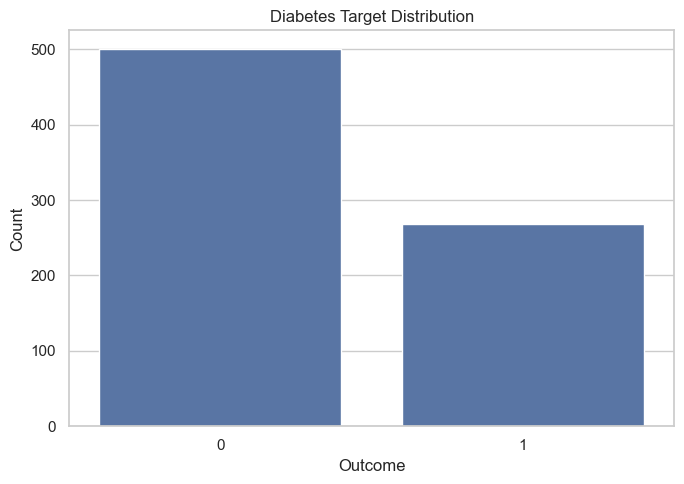

In [30]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Diabetes Target Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_diabetes_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


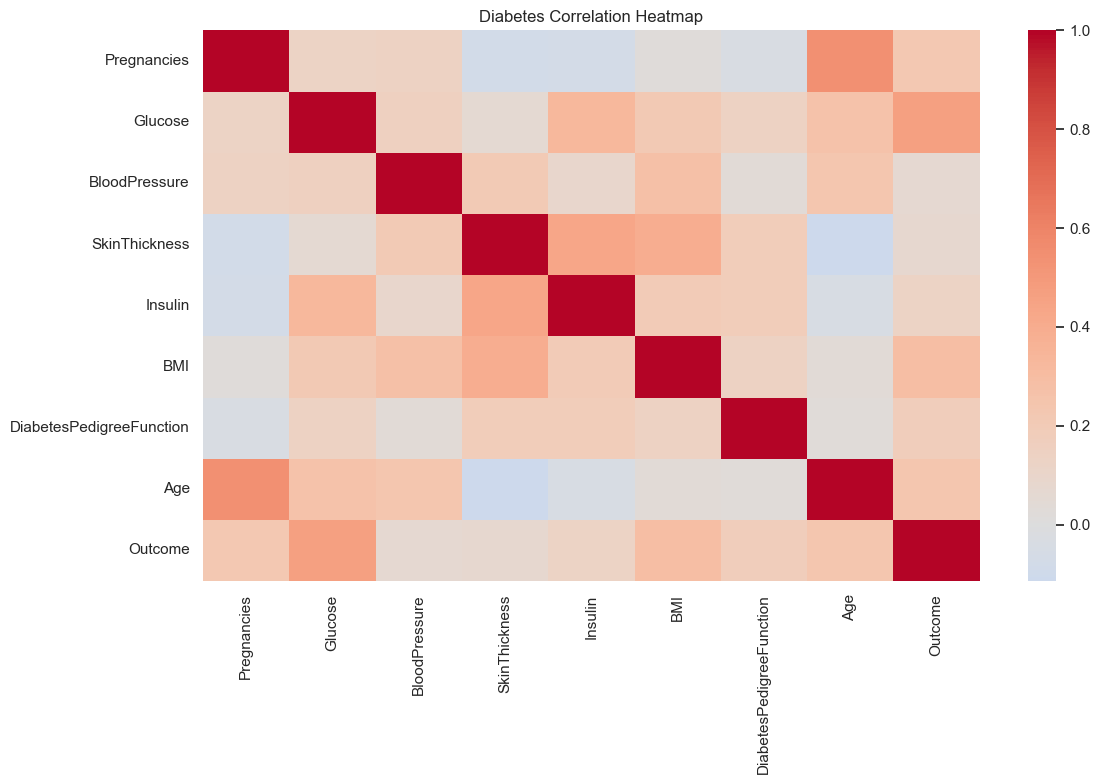

In [31]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Diabetes Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_diabetes_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


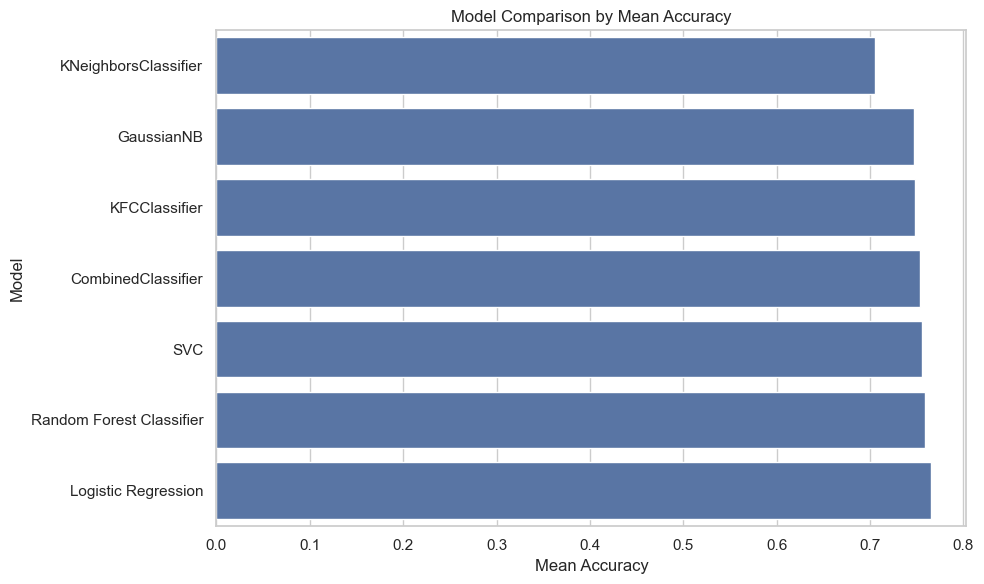

In [32]:
model_comparison_data = aggregated_results_flat.sort_values("Accuracy mean", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_comparison_data,
    x="Accuracy mean",
    y="Model",
    orient="h",
)
plt.title("Model Comparison by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_model_comparison_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


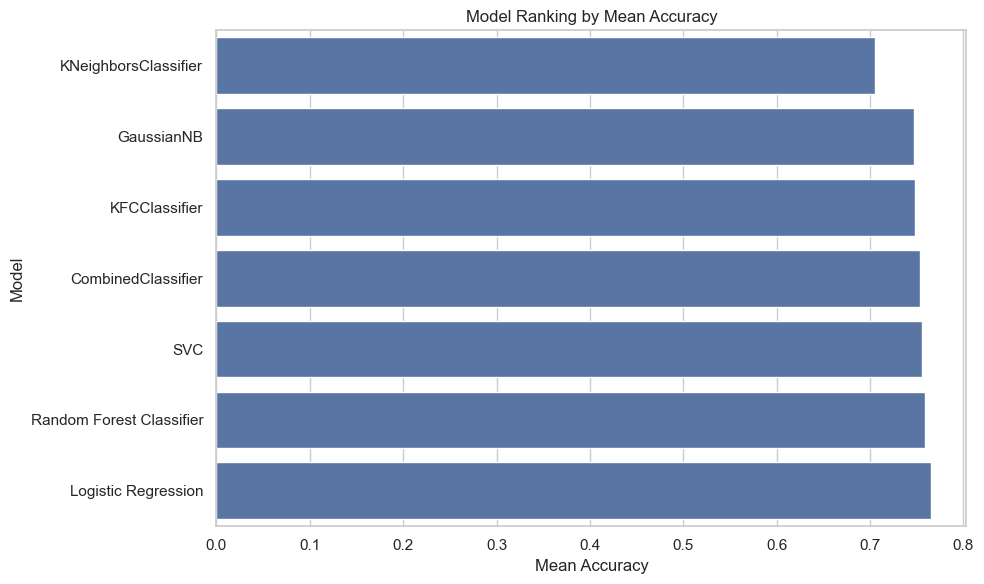

In [33]:
ranking_plot_data = ranking_table.sort_values("Rank", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_plot_data,
    x=f"Mean {PRIMARY_METRIC}",
    y="Model",
    orient="h",
)
plt.title("Model Ranking by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_ranking_chart.png", dpi=300, bbox_inches="tight")
plt.show()


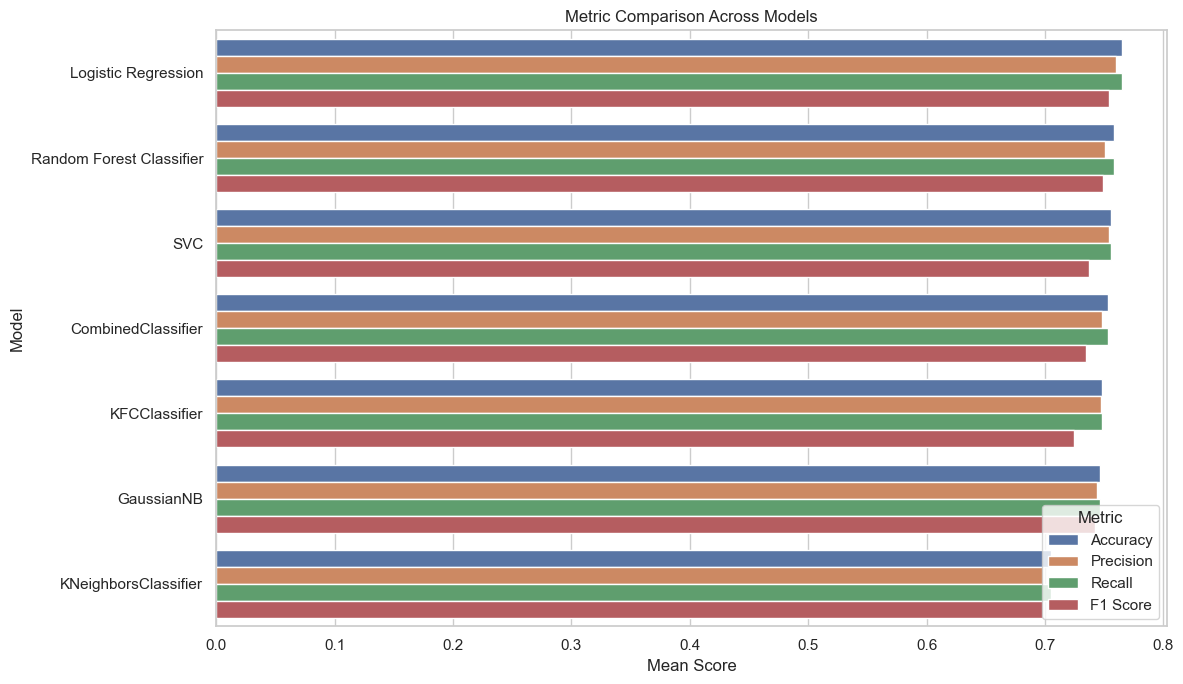

In [34]:
metric_comparison_data = aggregated_results_flat[
    ["Model"] + [f"{metric} mean" for metric in METRIC_COLUMNS]
].copy()

metric_comparison_data = metric_comparison_data.rename(
    columns={f"{metric} mean": metric for metric in METRIC_COLUMNS}
)

metric_comparison_long = metric_comparison_data.melt(
    id_vars="Model",
    value_vars=METRIC_COLUMNS,
    var_name="Metric",
    value_name="Mean Score",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    hue="Metric",
    orient="h",
)
plt.title("Metric Comparison Across Models")
plt.xlabel("Mean Score")
plt.ylabel("Model")
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. LaTeX-Ready Tables

The following cells generate LaTeX tables from computed notebook results.

No metric values are manually inserted.


In [35]:
latex_per_seed_table = per_seed_results_table.drop(columns=["Error Message"]).to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Diabetes classification results.",
    label="tab:diabetes_per_seed_results",
)

(TABLE_DIR / "diabetes_per_seed_results.tex").write_text(latex_per_seed_table)
print(latex_per_seed_table)


\begin{table}
\caption{Per-seed Diabetes classification results.}
\label{tab:diabetes_per_seed_results}
\begin{tabular}{lrrrrrrrl}
\toprule
Model & Seed & Accuracy & Precision & Recall & F1 Score & Fit Time & Prediction Time & Status \\
\midrule
CombinedClassifier & 42 & 0.7208 & 0.7103 & 0.7208 & 0.7056 & 1.1580 & 0.0081 & success \\
GaussianNB & 42 & 0.7078 & 0.7179 & 0.7078 & 0.7114 & 0.0008 & 0.0004 & success \\
KFCClassifier & 42 & 0.7273 & 0.7177 & 0.7273 & 0.7137 & 0.9816 & 0.0030 & success \\
KNeighborsClassifier & 42 & 0.6688 & 0.6622 & 0.6688 & 0.6648 & 0.0006 & 0.0009 & success \\
Logistic Regression & 42 & 0.7143 & 0.7065 & 0.7143 & 0.7084 & 0.0060 & 0.0006 & success \\
Random Forest Classifier & 42 & 0.7727 & 0.7676 & 0.7727 & 0.7673 & 0.0579 & 0.0032 & success \\
SVC & 42 & 0.7208 & 0.7106 & 0.7208 & 0.7031 & 0.0141 & 0.0018 & success \\
CombinedClassifier & 52 & 0.7987 & 0.7982 & 0.7987 & 0.7895 & 0.8641 & 0.0071 & success \\
GaussianNB & 52 & 0.7468 & 0.7410 & 0.7468 & 

In [36]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Diabetes classification results across five random seeds.",
    label="tab:diabetes_aggregated_results",
)

(TABLE_DIR / "diabetes_aggregated_results.tex").write_text(latex_aggregated_table)
print(latex_aggregated_table)


\begin{table}
\caption{Aggregated Diabetes classification results across five random seeds.}
\label{tab:diabetes_aggregated_results}
\begin{tabular}{lllll}
\toprule
Model & Accuracy & Precision & Recall & F1 Score \\
\midrule
Logistic Regression & 0.765 ± 0.050 & 0.760 ± 0.055 & 0.765 ± 0.050 & 0.754 ± 0.055 \\
Random Forest Classifier & 0.758 ± 0.045 & 0.751 ± 0.050 & 0.758 ± 0.045 & 0.749 ± 0.052 \\
SVC & 0.756 ± 0.044 & 0.754 ± 0.053 & 0.756 ± 0.044 & 0.737 ± 0.049 \\
CombinedClassifier & 0.753 ± 0.047 & 0.749 ± 0.053 & 0.753 ± 0.047 & 0.735 ± 0.060 \\
KFCClassifier & 0.748 ± 0.044 & 0.747 ± 0.054 & 0.748 ± 0.044 & 0.724 ± 0.058 \\
GaussianNB & 0.747 ± 0.040 & 0.744 ± 0.040 & 0.747 ± 0.040 & 0.743 ± 0.042 \\
KNeighborsClassifier & 0.705 ± 0.042 & 0.698 ± 0.045 & 0.705 ± 0.042 & 0.698 ± 0.043 \\
\bottomrule
\end{tabular}
\end{table}



In [37]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean accuracy for the Diabetes classification experiment.",
    label="tab:diabetes_model_ranking",
)

(TABLE_DIR / "diabetes_model_ranking.tex").write_text(latex_ranking_table)
print(latex_ranking_table)


\begin{table}
\caption{Model ranking by mean accuracy for the Diabetes classification experiment.}
\label{tab:diabetes_model_ranking}
\begin{tabular}{rlrr}
\toprule
Rank & Model & Mean Accuracy & Std Accuracy \\
\midrule
1 & Logistic Regression & 0.7649 & 0.0504 \\
2 & Random Forest Classifier & 0.7584 & 0.0451 \\
3 & SVC & 0.7558 & 0.0437 \\
4 & CombinedClassifier & 0.7532 & 0.0468 \\
5 & KFCClassifier & 0.7481 & 0.0439 \\
6 & GaussianNB & 0.7468 & 0.0400 \\
7 & KNeighborsClassifier & 0.7052 & 0.0422 \\
\bottomrule
\end{tabular}
\end{table}



## 15. Discussion

### Comparison of Baselines

The baseline classifiers establish the reference performance level for the Diabetes classification task. The comparison should be based on the aggregated results table rather than on a single train-test split.

The ranking table identifies which baseline classifier achieves the highest mean accuracy across the five required seeds.

### Comparison of COBRA Models

The classification-appropriate COBRA model used in this notebook is `CombinedClassifier`.

`GradientCOBRA` and `MixCOBRARegressor` are not used because they are regression-oriented. Their use in this classification task would not be methodologically appropriate.

The performance of `CombinedClassifier` should be interpreted by comparing its mean accuracy, precision, recall, and F1-score against the baseline classifiers.

### Comparison of KFC Models

The KFCProcedure model is represented by `KFCClassifier`.

The KFCClassifier applies:

- K-Step: divergence-based clustering
- F-Step: cluster-wise logistic regression
- C-Step: COBRA-based aggregation through `combined_classifier`

Its performance should be compared with both baseline classifiers and standalone `CombinedClassifier`.

### Strengths

The experiment has the following strengths:

1. It uses repeated evaluation over five random seeds.
2. Each model is evaluated on the same seed-specific train-test split.
3. The train-test split is stratified by the target variable.
4. Scaling for KFC is fitted only on the training split to prevent leakage.
5. The same classification metrics are used for all models.
6. The notebook reports both per-seed results and mean ± standard deviation.

### Limitations

The experiment has the following limitations:

1. The dataset is relatively small.
2. Hyperparameter tuning beyond repository-supported configurations is not introduced.
3. Outlier handling is not applied because it is not observable from the provided materials.
4. Feature selection is not applied because it is not observable from the provided materials.
5. Baseline models are trained on raw features to remain consistent with the provided Diabetes notebook, while KFC uses MinMax-scaled features for divergence compatibility.
6. Duplicate removal is not applied because it is not observable from the provided Diabetes notebook.

### Threats to Validity

Potential threats to validity include:

1. Results may change under alternative preprocessing choices.
2. Results may change under tuned hyperparameter settings.
3. The selected train-test protocol may not fully capture uncertainty compared with nested cross-validation.
4. The dataset may not generalize to other clinical diabetes datasets.
5. More complex aggregation models may be less interpretable than simpler baseline classifiers.


In [38]:
baseline_model_names = [
    "Logistic Regression",
    "Random Forest Classifier",
    "SVC",
    "KNeighborsClassifier",
    "GaussianNB",
]

baseline_ranking = ranking_table[ranking_table["Model"].isin(baseline_model_names)].reset_index(drop=True)
cobra_result = ranking_table[ranking_table["Model"] == "CombinedClassifier"].reset_index(drop=True)
kfc_result = ranking_table[ranking_table["Model"] == "KFCClassifier"].reset_index(drop=True)

print("Baseline model ranking:")
display(baseline_ranking)

print("COBRA result:")
display(cobra_result)

print("KFC result:")
display(kfc_result)


Baseline model ranking:


,Rank,Model,Mean Accuracy,Std Accuracy
0,1,Logistic Regression,0.764935,0.050382
1,2,Random Forest Classifier,0.758442,0.045082
2,3,SVC,0.755844,0.043705
3,6,GaussianNB,0.746753,0.040029
4,7,KNeighborsClassifier,0.705195,0.042233


COBRA result:


,Rank,Model,Mean Accuracy,Std Accuracy
0,4,CombinedClassifier,0.753247,0.046825


KFC result:


,Rank,Model,Mean Accuracy,Std Accuracy
0,5,KFCClassifier,0.748052,0.043897


## 16. Conclusion

This notebook implemented a complete Diabetes classification experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated:

1. Baseline machine learning classifiers
2. `CombinedClassifier`
3. `KFCClassifier`

The methodology emphasized reproducibility and statistical reporting by using repeated evaluation with the required seeds:

```python
[42, 52, 62, 72, 82]
```

For each seed, the dataset was split, models were trained, predictions were generated, and classification metrics were stored. The final results were summarized using mean and standard deviation for Accuracy, Precision, Recall, and F1-score.

The final thesis interpretation should rely only on the computed per-seed, aggregated, and ranking tables generated by this notebook. No performance claim should be made without referring to those computed results.


## 17. Reproducibility Checklist

The notebook follows these reproducibility controls:

- Dataset source is explicitly stated.
- Target variable is explicitly defined as `Outcome`.
- Repeated seeds are explicitly defined.
- Train-test split is stratified.
- Preprocessing is applied inside each seed-specific experiment.
- KFC scaling is fitted on training data only.
- All model results are stored in `all_results`.
- Per-seed results are reported.
- Aggregated mean and standard deviation are reported.
- Ranking is computed from the primary metric.
- LaTeX-ready tables are generated from computed values.
- Figures are saved for thesis use.
